<a href="https://colab.research.google.com/github/lhgiangg/NLP/blob/main/lab3_truyenkieu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving lab_2_truyen_kieu.txt to lab_2_truyen_kieu.txt


In [ ]:
with open('lab_2_truyen_kieu.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(text[:500])

1..Trăm năm trong cõi người ta,
2..Chữ tài chữ mệnh khéo là ghét nhau.
3..Trải qua một cuộc bể dâu,
4..Những điều trông thấy mà đau đớn lòng.
5.. Lạ gì bỉ sắc tư phong,
6..Trời xanh quen thói má hồng đánh ghen.
7..Cảo thơm lần giở trước đèn,
8..Phong tình có lục còn truyền sử xanh.
9,,Rằng năm Gia Tĩnh triều Minh,
10.. Bốn phương phẳng lặng, hai kinh vững vàng.
11..Có nhà viên ngoại họ Vương,
12..Gia tư nghĩ cũng thường thường bực trung.
13..Một trai con thứ rốt lòng,
14..Vương Quan là chữ, nối 


In [ ]:
import re

In [ ]:
def preprocess_text(text):

    # 1. Chuyển thành chữ thường
    text = text.lower()

    # 2. Loại bỏ ký tự đặc biệt
    text = re.sub(r'[^a-zA-ZÀ-ỹ0-9\s\n]', '', text)

    # 3. Tách thành từng dòng/câu
    lines = text.split('\n')

    processed_sentences = []

    for line in lines:
        line = line.strip()

        if len(line) == 0:
            continue

        # 4. Tách từ đơn
        words = line.split()

        # 5. Thêm token bắt đầu và kết thúc câu
        words = ['<s>'] + words + ['</s>']

        processed_sentences.append(words)

    return processed_sentences

In [ ]:
sentences = preprocess_text(text)

In [ ]:
for s in sentences[:5]:
    print(s)

['<s>', '1trăm', 'năm', 'trong', 'cõi', 'người', 'ta', '</s>']
['<s>', '2chữ', 'tài', 'chữ', 'mệnh', 'khéo', 'là', 'ghét', 'nhau', '</s>']
['<s>', '3trải', 'qua', 'một', 'cuộc', 'bể', 'dâu', '</s>']
['<s>', '4những', 'điều', 'trông', 'thấy', 'mà', 'đau', 'đớn', 'lòng', '</s>']
['<s>', '5', 'lạ', 'gì', 'bỉ', 'sắc', 'tư', 'phong', '</s>']


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
all_words = []

for sentence in sentences:
    all_words.extend(sentence)

In [ ]:
vocab = set(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 3124


In [ ]:
word_freq = Counter(all_words)

In [ ]:
print(word_freq.most_common(10))

[('<s>', 3258), ('</s>', 3258), ('một', 318), ('đã', 260), ('người', 224), ('nàng', 200), ('lòng', 174), ('lời', 171), ('cho', 171), ('là', 170)]


In [ ]:
word_freq.pop('<s>', None)
word_freq.pop('</s>', None)

3258

In [ ]:
top10 = word_freq.most_common(10)

words = [w[0] for w in top10]
counts = [w[1] for w in top10]

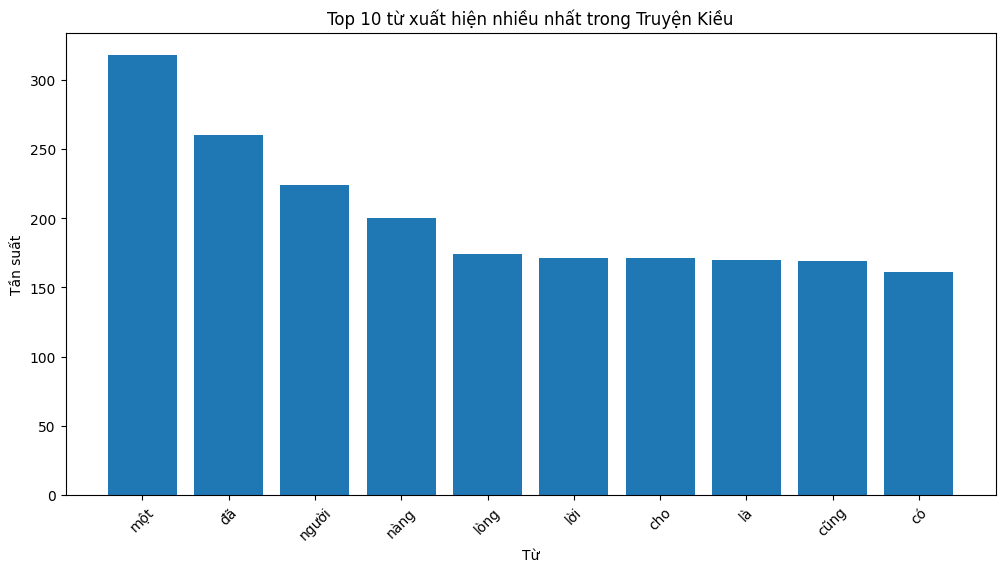

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title("Top 10 từ xuất hiện nhiều nhất trong Truyện Kiều")
plt.xlabel("Từ")
plt.ylabel("Tần suất")

plt.xticks(rotation=45)

plt.show()

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
bigrams = []

for sentence in sentences:
    for i in range(len(sentence) - 1):
        bg = (sentence[i], sentence[i+1])
        bigrams.append(bg)

In [ ]:
print(bigrams[:10])

[('<s>', '1trăm'), ('1trăm', 'năm'), ('năm', 'trong'), ('trong', 'cõi'), ('cõi', 'người'), ('người', 'ta'), ('ta', '</s>'), ('<s>', '2chữ'), ('2chữ', 'tài'), ('tài', 'chữ')]


In [ ]:
bigram_freq = Counter(bigrams)

In [ ]:
top10_bigrams = bigram_freq.most_common(10)

print(top10_bigrams)

[(('<s>', 'một'), 64), (('<s>', 'nàng'), 53), (('lời', '</s>'), 44), (('người', '</s>'), 43), (('tình', '</s>'), 42), (('hoa', '</s>'), 38), (('xa', '</s>'), 38), (('đây', '</s>'), 36), (('lòng', '</s>'), 35), (('nhà', '</s>'), 35)]


In [ ]:
labels = [' '.join(bg[0]) for bg in top10_bigrams]
counts = [bg[1] for bg in top10_bigrams]

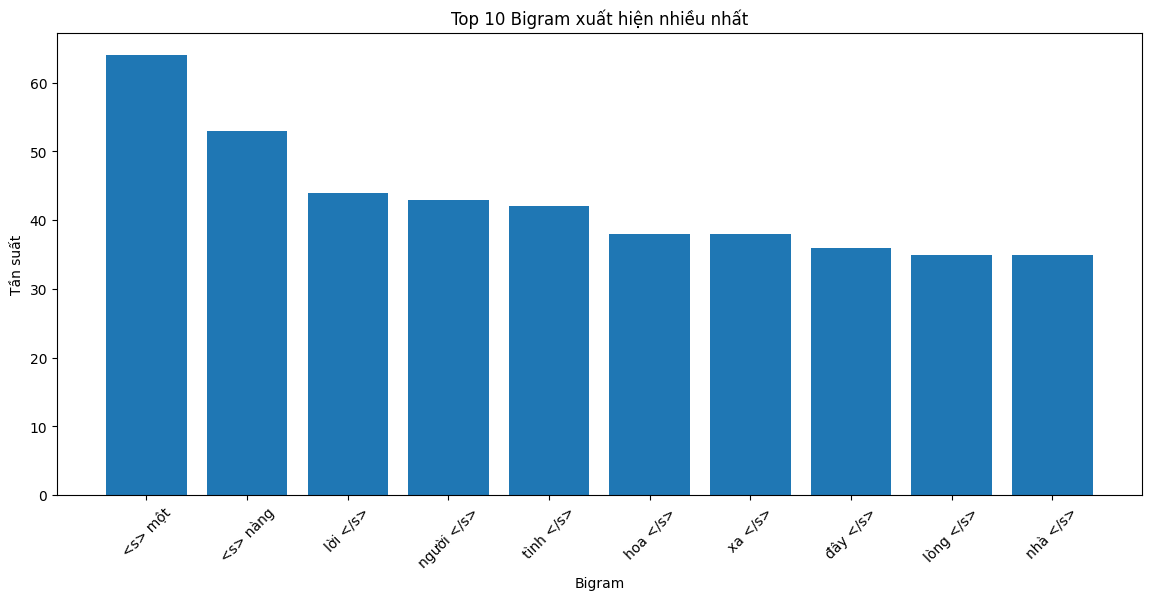

In [ ]:
plt.figure(figsize=(14,6))

plt.bar(labels, counts)

plt.title("Top 10 Bigram xuất hiện nhiều nhất")
plt.xlabel("Bigram")
plt.ylabel("Tần suất")

plt.xticks(rotation=45)

plt.show()

In [ ]:
def bigram_probability(w1, w2):

    bigram_count = bigram_freq[(w1, w2)]
    unigram_count = word_freq[w1]

    if unigram_count == 0:
        return 0

    return bigram_count / unigram_count

In [ ]:
prob = bigram_probability('trăm', 'năm')

print("P(năm | trăm) =", prob)

P(năm | trăm) = 0.26666666666666666


In [ ]:
examples = [
    ('trăm', 'năm'),
    ('một', 'ngày'),
    ('đã', 'cho'),
    ('thế', 'gian')
]

for w1, w2 in examples:
    p = bigram_probability(w1, w2)
    print(f"P({w2} | {w1}) = {p:.4f}")

P(năm | trăm) = 0.2667
P(ngày | một) = 0.0440
P(cho | đã) = 0.0077
P(gian | thế) = 0.0000


In [ ]:
V = len(vocab)

def bigram_probability_smoothing(w1, w2):

    bigram_count = bigram_freq[(w1, w2)]
    unigram_count = word_freq[w1]

    return (bigram_count + 1) / (unigram_count + V)

In [ ]:
prob = bigram_probability_smoothing('trăm', 'năm')

print(prob)

0.0028535193405199747


In [ ]:
import random

In [ ]:
bigram_model = {}

for (w1, w2), count in bigram_freq.items():

    if w1 not in bigram_model:
        bigram_model[w1] = []

    # thêm w2 nhiều lần theo tần suất
    bigram_model[w1].extend([w2] * count)

In [ ]:
def generate_sentence(num_words):

    current_word = '<s>'

    sentence = []

    while len(sentence) < num_words:

        next_words = bigram_model.get(current_word, None)

        if not next_words:
            break

        next_word = random.choice(next_words)

        if next_word == '</s>':
            current_word = '<s>'
            continue

        sentence.append(next_word)

        current_word = next_word

    return ' '.join(sentence)

In [ ]:
def generate_luc_bat():

    cau_6 = generate_sentence(6)
    cau_8 = generate_sentence(8)

    return cau_6, cau_8

In [ ]:
for i in range(5):

    luc, bat = generate_luc_bat()

    print("Câu 6:", luc)
    print("Câu 8:", bat)
    print()

Câu 6: 1660 giếng khơi diện quốc biết
Câu 8: vườn ta thì dẹp nỗi thảm thiết vị

Câu 6: chàng 890sống nhờ đất ghen tuông
Câu 8: lượng cả hai đường bộ tên rằng hồng

Câu 6: 625 hỏi quê phận thơ chẳng
Câu 8: 2225 bằng lộc gồm tài mạo tót vời

Câu 6: từ chiếc bóng năm nữa cái
Câu 8: 2140 cũng sẽ liệu với ai một lời

Câu 6: 1845 sinh càng lã chã khôn
Câu 8: xót thương thầm yêu được một tượng trắng



In [ ]:
for i in range(2):

    cau_6, cau_8 = generate_luc_bat()

    print(f"=== Cặp thơ {i+1} ===")
    print(cau_6)
    print(cau_8)
    print()

=== Cặp thơ 1 ===
1040 tin giữa giường giẽ run
tẩy oan đã mòn cỏ dàu vừa tuần

=== Cặp thơ 2 ===
nhập ra tựa nương bên trong
hoa tường vôi rộn đường hiếu làm sao



In [ ]:
trigrams = []

for sentence in sentences:

    for i in range(len(sentence) - 2):

        tg = (sentence[i], sentence[i+1], sentence[i+2])

        trigrams.append(tg)

In [ ]:
print(trigrams[:10])

[('<s>', '1trăm', 'năm'), ('1trăm', 'năm', 'trong'), ('năm', 'trong', 'cõi'), ('trong', 'cõi', 'người'), ('cõi', 'người', 'ta'), ('người', 'ta', '</s>'), ('<s>', '2chữ', 'tài'), ('2chữ', 'tài', 'chữ'), ('tài', 'chữ', 'mệnh'), ('chữ', 'mệnh', 'khéo')]


In [ ]:
trigram_freq = Counter(trigrams)

In [ ]:
print(trigram_freq.most_common(10))

[(('<s>', 'nàng', 'rằng'), 24), (('<s>', 'tiểu', 'thư'), 17), (('<s>', 'một', 'lời'), 11), (('<s>', 'những', 'là'), 11), (('<s>', 'cùng', 'nhau'), 11), (('<s>', 'bây', 'giờ'), 10), (('<s>', 'giác', 'duyên'), 10), (('thì', 'thôi', '</s>'), 9), (('bấy', 'lâu', '</s>'), 9), (('thế', 'này', '</s>'), 9)]


In [ ]:
def trigram_probability(w1, w2, w3):

    trigram_count = trigram_freq[(w1, w2, w3)]
    bigram_count = bigram_freq[(w1, w2)]

    if bigram_count == 0:
        return 0

    return trigram_count / bigram_count

In [ ]:
p = trigram_probability('trăm', 'năm', 'trong')

print("P(trong | trăm năm) =", p)

P(trong | trăm năm) = 0.0


In [ ]:
V = len(vocab)

def trigram_probability_smoothing(w1, w2, w3):

    trigram_count = trigram_freq[(w1, w2, w3)]
    bigram_count = bigram_freq[(w1, w2)]

    return (trigram_count + 1) / (bigram_count + V)

In [ ]:
trigram_model = {}

for (w1, w2, w3), count in trigram_freq.items():

    key = (w1, w2)

    if key not in trigram_model:
        trigram_model[key] = []

    trigram_model[key].extend([w3] * count)

In [ ]:
import random

def generate_sentence_trigram(num_words):

    w1, w2 = '<s>', random.choice(list(vocab))

    sentence = []

    while len(sentence) < num_words:

        key = (w1, w2)

        next_words = trigram_model.get(key, None)

        if not next_words:
            break

        w3 = random.choice(next_words)

        if w3 == '</s>':
            break

        sentence.append(w3)

        w1, w2 = w2, w3

    return ' '.join(sentence)

In [ ]:
def generate_luc_bat_trigram():

    cau_6 = generate_sentence_trigram(6)
    cau_8 = generate_sentence_trigram(8)

    return cau_6, cau_8

In [ ]:
for i in range(2):

    luc, bat = generate_luc_bat_trigram()

    print(f"=== Cặp thơ {i+1} ===")
    print(luc)
    print(bat)
    print()

=== Cặp thơ 1 ===

dằng chưa nỡ rời

=== Cặp thơ 2 ===



